# Visualize Rasterized Dataset

Loads episodes from `largemaze_ellipsoids_2-v1_rasterized` and shows for each episode:
- **Left**: world-coordinate view (maze walls + ellipsoids + trajectory)
- **Right**: rasterized bitmap view (occupancy map + trajectory overlaid in pixel space)

In [1]:
# PARAMETERS
RASTERIZED_DATASET_DIR = './data/custom/largemaze_ellipsoids-v1_rasterized'
NUM_SAMPLES = 6       # number of random episodes to show
RANDOM_SEED = 42      # set to None for a fresh random selection each run

In [3]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------------------------------------------------
# Load dataset metadata
# -----------------------------------------------------------------------
meta_path = os.path.join(RASTERIZED_DATASET_DIR, 'metadata.json')
with open(meta_path) as f:
    meta = json.load(f)

N_EPISODES = meta['n_episodes']
H = meta['bitmap_H']
W = meta['bitmap_W']
xy_min   = np.array(meta['xy_min'],   dtype=np.float32)
xy_range = np.array(meta['xy_range'], dtype=np.float32)

print(f"Dataset: {meta['source_dataset']}")
print(f"Episodes: {N_EPISODES},  T_steps: {meta['T_steps']},  bitmap: {H}x{W}")
print(f"xy_min={xy_min},  xy_range={xy_range}")


def load_episode(idx):
    path = os.path.join(RASTERIZED_DATASET_DIR, 'episodes', f'episode_{idx}.npz')
    return dict(np.load(path))

Dataset: custom/largemaze_ellipsoids-v1
Episodes: 10505,  T_steps: 64,  bitmap: 64x64
xy_min=[-4.9382844 -3.4389195],  xy_range=[9.88382   6.8959484]


In [4]:
# -----------------------------------------------------------------------
# World-space drawing helpers  (matches train notebook style)
# -----------------------------------------------------------------------
_MAZE_MAP = [
    [1,1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,0,1,0,1],
    [1,0,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,1,0,1,1,1,0,1],
    [1,0,0,1,0,1,0,0,0,0,0,1],
    [1,1,0,1,0,1,0,1,0,1,1,1],
    [1,0,0,1,0,0,0,1,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1,1],
]

def draw_maze(ax):
    for i, row in enumerate(_MAZE_MAP):
        for j, cell in enumerate(row):
            if cell:
                rect = plt.Rectangle((-5.5 + j - 0.5, 4.0 - i - 0.5), 1.0, 1.0,
                                     linewidth=0, facecolor='dimgray')
                ax.add_patch(rect)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-4.5, 4.5)


def draw_ellipsoid(ax, cx, cy, a, b, color='steelblue', alpha=0.4):
    """Degree-4 superellipse outline matching the rasterize.py obstacle shape."""
    t = np.linspace(0, 2 * np.pi, 300)
    # |x/a|^4 + |y/b|^4 = 1  parametric boundary
    cos_t, sin_t = np.cos(t), np.sin(t)
    x = cx + a * np.sign(cos_t) * np.abs(cos_t) ** 0.5
    y = cy + b * np.sign(sin_t) * np.abs(sin_t) ** 0.5
    ax.add_patch(plt.Polygon(
        np.column_stack([x, y]),
        facecolor=color, edgecolor=color, alpha=alpha,
    ))


def world_to_pixel(xy_world, H, W, xy_min, xy_range):
    """Convert world (x,y) to pixel (col, row) for imshow with origin='lower'."""
    xy_norm = 2.0 * (xy_world - xy_min) / xy_range - 1.0   # [-1, 1]
    col = (xy_norm[:, 0] + 1.0) / 2.0 * (W - 1)            # x -> column
    row = (xy_norm[:, 1] + 1.0) / 2.0 * (H - 1)            # y -> row (origin=lower)
    return col, row

In [5]:
# -----------------------------------------------------------------------
# Select episodes
# -----------------------------------------------------------------------
rng = np.random.default_rng(RANDOM_SEED)
selected_ids = rng.choice(N_EPISODES, size=min(NUM_SAMPLES, N_EPISODES), replace=False)
selected_ids = sorted(selected_ids)
print(f"Selected episode indices: {selected_ids}")

Selected episode indices: [np.int64(937), np.int64(4548), np.int64(4609), np.int64(6874), np.int64(8127), np.int64(9019)]


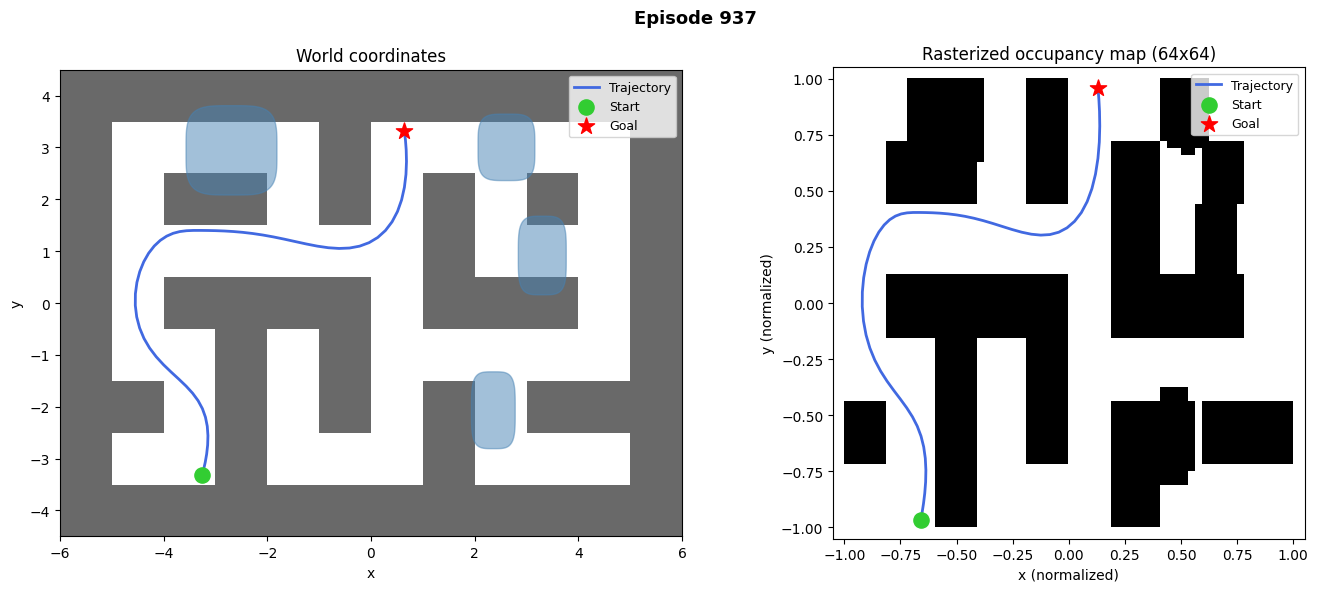

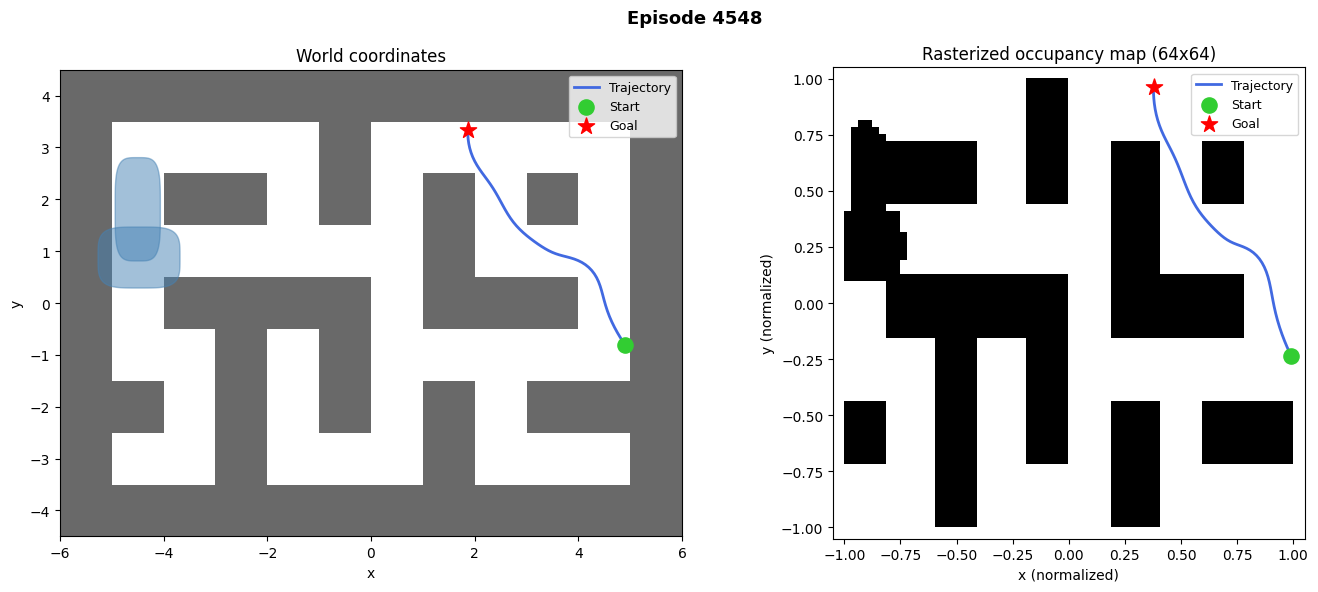

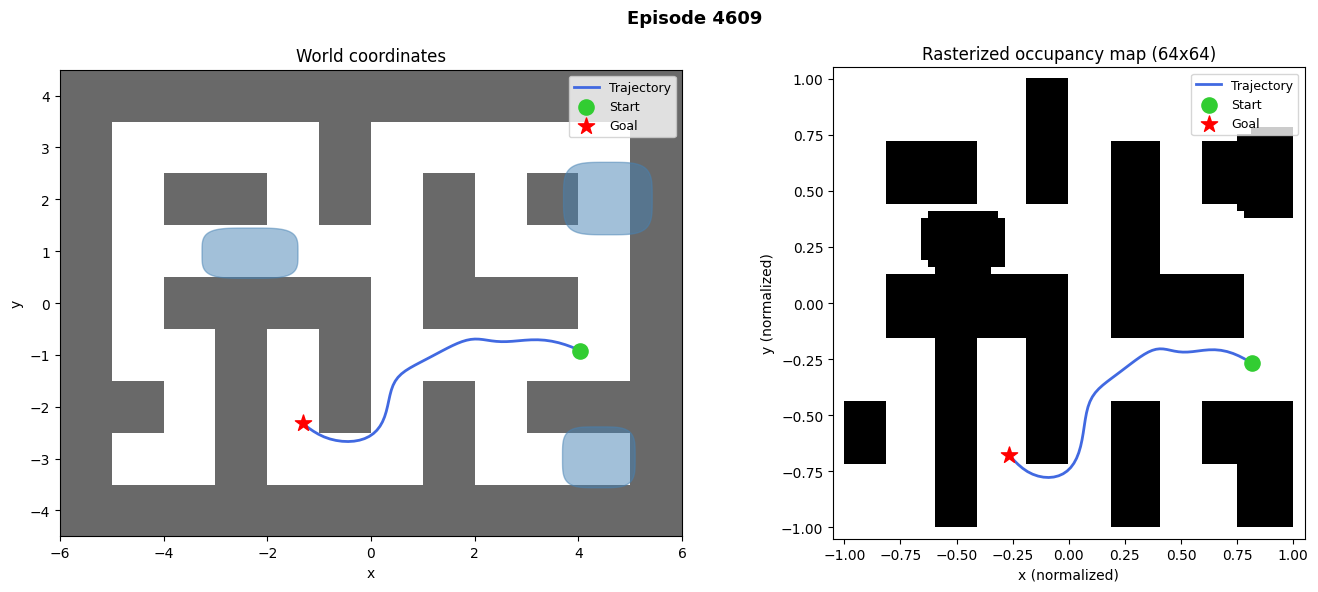

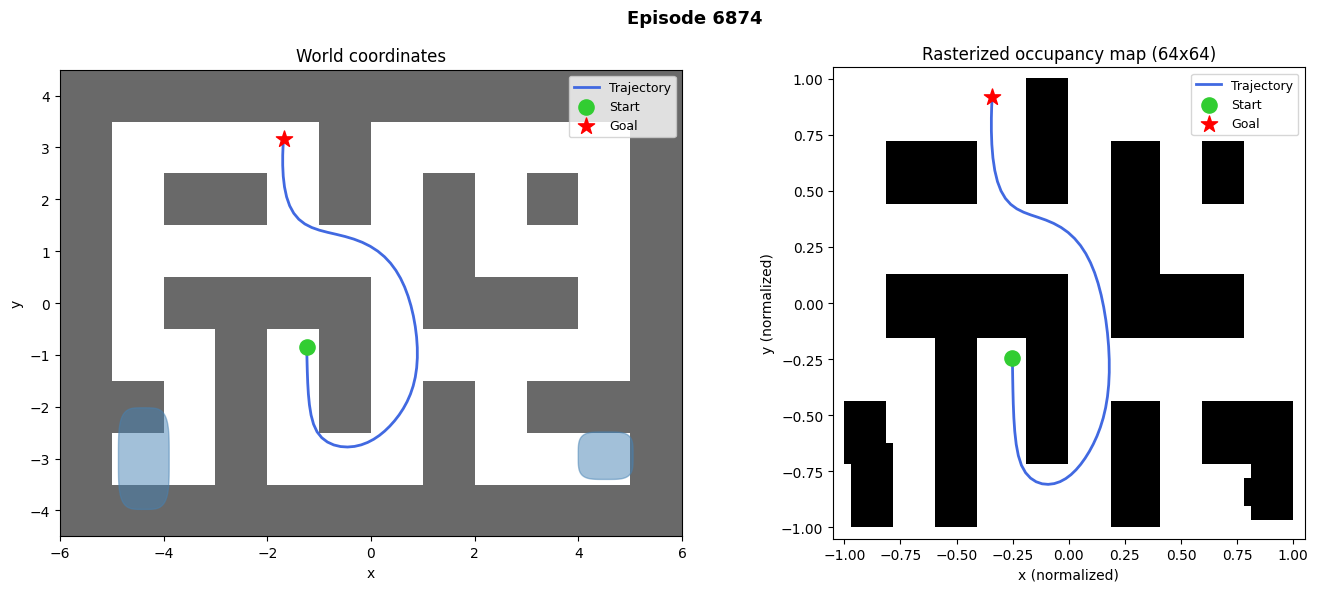

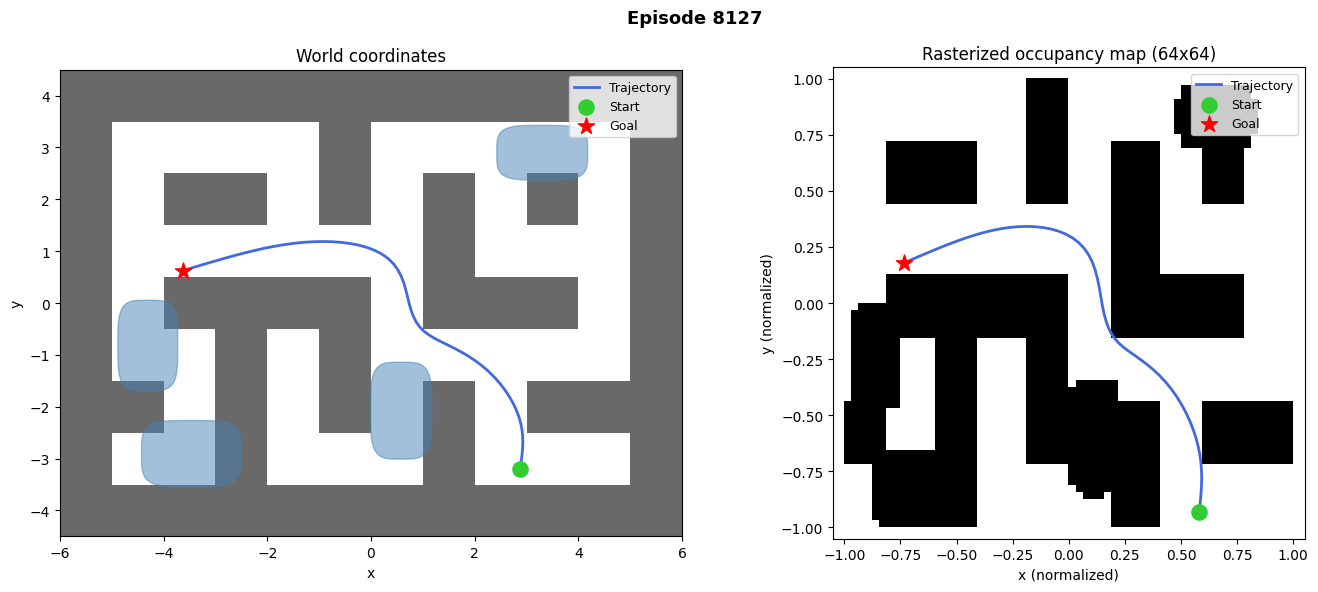

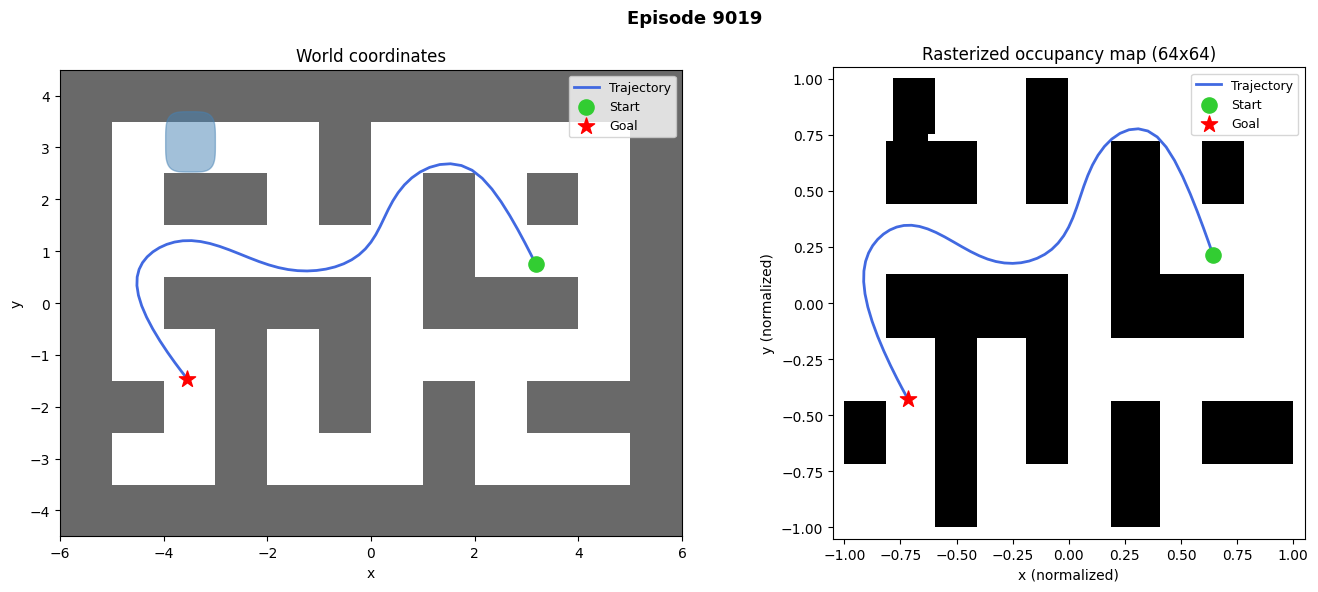

In [6]:
# -----------------------------------------------------------------------
# Main visualization — world view  |  rasterized view
# -----------------------------------------------------------------------
for ep_idx in selected_ids:
    ep = load_episode(ep_idx)

    occ_map         = ep['occ_map'][0]          # [H, W]
    traj_world      = ep['trajectory']          # [T, 4]  x,y,vx,vy
    traj_xy         = traj_world[:, :2]         # [T, 2]
    start_w         = ep['start_pos']           # [2]
    goal_w          = ep['goal_pos']            # [2]
    ell_world       = ep['ellipsoids_world']    # [5, 4]  cx,cy,a,b
    ep_xy_min       = ep['xy_min']              # [2]
    ep_xy_range     = ep['xy_range']            # [2]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Episode {ep_idx}', fontsize=13, fontweight='bold')

    # ---- Left: world-coordinate view --------------------------------
    draw_maze(ax1)
    for row in ell_world:
        cx, cy, a, b = row
        if a > 1e-4:
            draw_ellipsoid(ax1, cx, cy, a, b, color='steelblue', alpha=0.5)

    ax1.plot(traj_xy[:, 0], traj_xy[:, 1],
             color='royalblue', linewidth=2, label='Trajectory', zorder=4)
    ax1.scatter(start_w[0], start_w[1],
                color='limegreen', s=120, zorder=5, label='Start')
    ax1.scatter(goal_w[0], goal_w[1],
                color='red', s=150, marker='*', zorder=5, label='Goal')

    ax1.set_aspect('equal')
    ax1.set_title('World coordinates')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.set_xlabel('x'); ax1.set_ylabel('y')

    # ---- Right: rasterized bitmap view ------------------------------
    ax2.imshow(occ_map, origin='lower', cmap='gray_r',
               extent=[-1, 1, -1, 1], vmin=0, vmax=1)

    # Trajectory in normalized [-1,1] space
    traj_norm = ep['trajectory_norm']           # [T, 4]  x_n,y_n,vx_n,vy_n
    ax2.plot(traj_norm[:, 0], traj_norm[:, 1],
             color='royalblue', linewidth=2, label='Trajectory', zorder=4)

    start_n = ep['start_norm']                  # [2]
    goal_n  = ep['goal_norm']                   # [2]
    ax2.scatter(start_n[0], start_n[1],
                color='limegreen', s=120, zorder=5, label='Start')
    ax2.scatter(goal_n[0], goal_n[1],
                color='red', s=150, marker='*', zorder=5, label='Goal')

    ax2.set_aspect('equal')
    ax2.set_title(f'Rasterized occupancy map ({H}x{W})')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.set_xlabel('x (normalized)'); ax2.set_ylabel('y (normalized)')
    ax2.set_xlim(-1.05, 1.05); ax2.set_ylim(-1.05, 1.05)

    plt.tight_layout()
    plt.show()

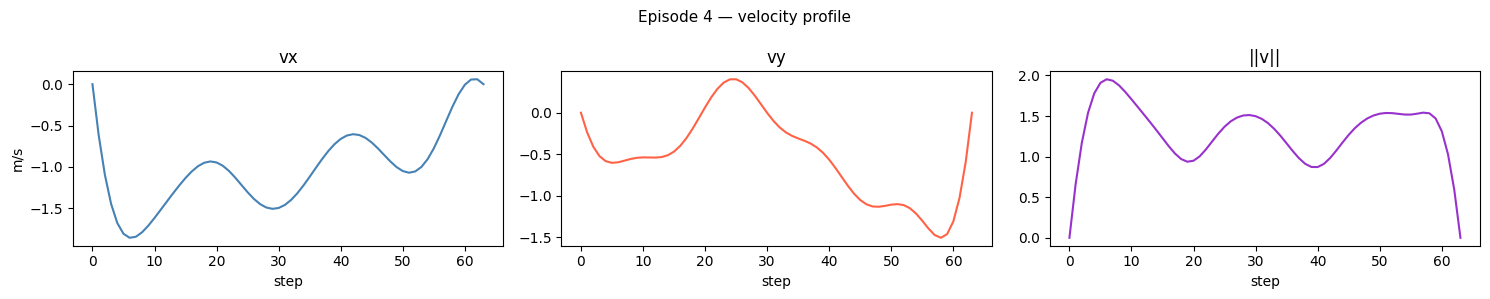

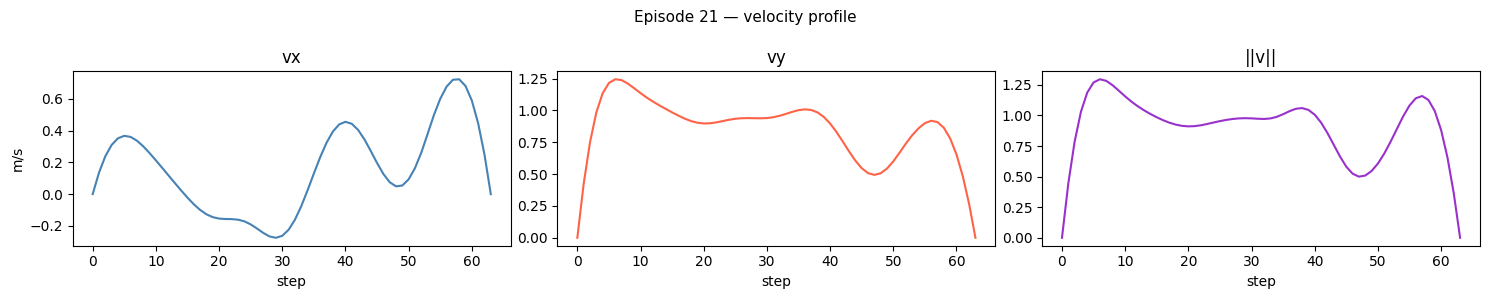

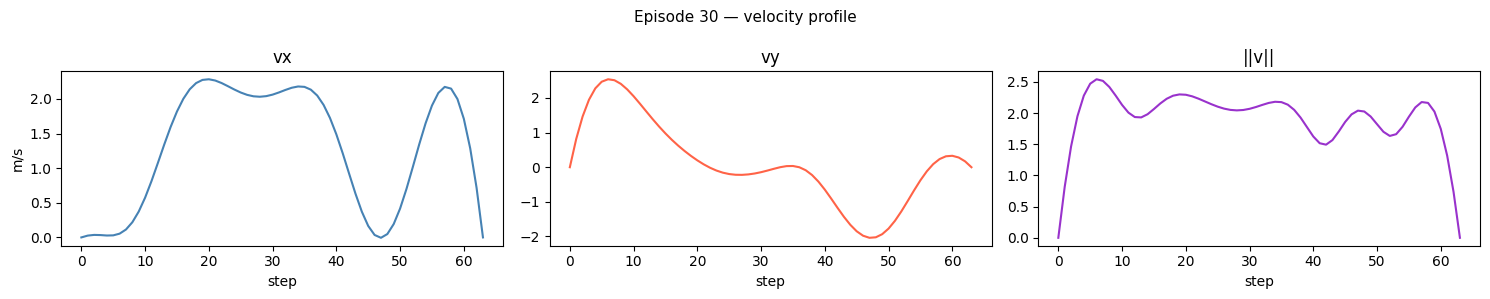

In [6]:
# -----------------------------------------------------------------------
# Velocity profile visualization
# -----------------------------------------------------------------------
for ep_idx in selected_ids[:3]:
    ep = load_episode(ep_idx)
    traj = ep['trajectory']       # [T, 4]
    T = traj.shape[0]
    t  = np.arange(T)
    speed = np.sqrt(traj[:, 2]**2 + traj[:, 3]**2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    fig.suptitle(f'Episode {ep_idx} — velocity profile', fontsize=11)

    axes[0].plot(t, traj[:, 2], color='steelblue')
    axes[0].set_title('vx'); axes[0].set_xlabel('step'); axes[0].set_ylabel('m/s')

    axes[1].plot(t, traj[:, 3], color='tomato')
    axes[1].set_title('vy'); axes[1].set_xlabel('step')

    axes[2].plot(t, speed, color='darkorchid')
    axes[2].set_title('||v||'); axes[2].set_xlabel('step')

    plt.tight_layout()
    plt.show()

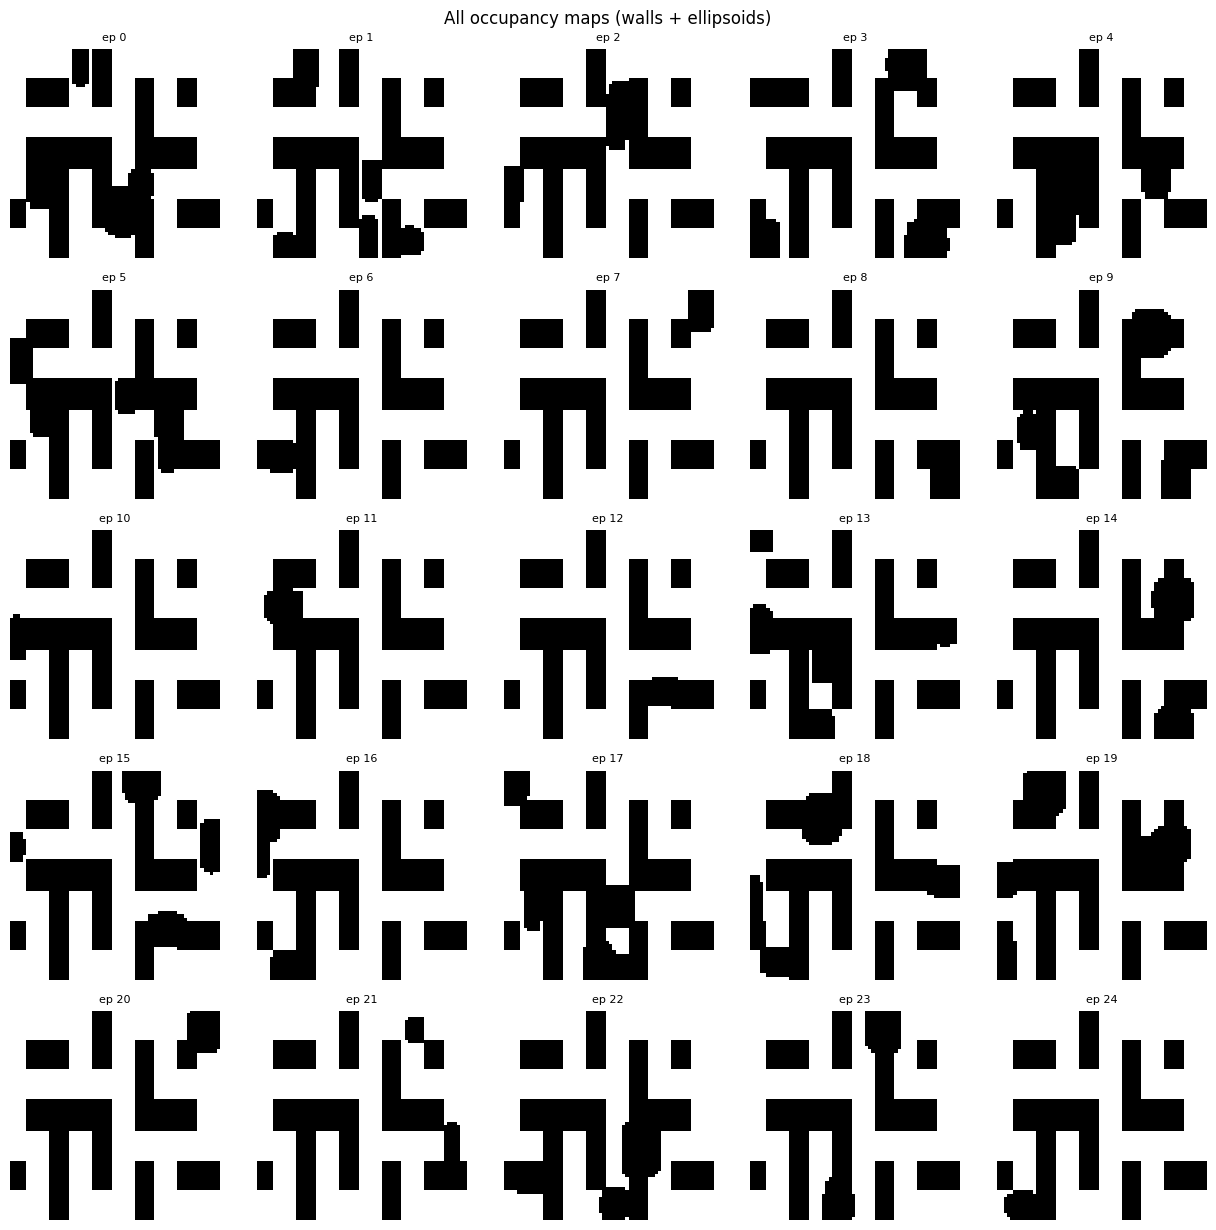

In [7]:
# -----------------------------------------------------------------------
# Dataset overview — all occupancy maps in a grid
# -----------------------------------------------------------------------
n_show = min(N_EPISODES, 25)
cols = 5
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
fig.suptitle('All occupancy maps (walls + ellipsoids)', fontsize=12)
axes = axes.flatten()

for i in range(n_show):
    ep = load_episode(i)
    axes[i].imshow(ep['occ_map'][0], origin='lower', cmap='gray_r', vmin=0, vmax=1)
    axes[i].set_title(f'ep {i}', fontsize=8)
    axes[i].axis('off')

for i in range(n_show, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()